In [175]:
# =================================
# 設定
# =================================
IS_ONLINE_JUDGE = False

LIMIT_QUERY_CNT = None

DEBUG = False
DEBUG_QUERY = None
DEBUG_L = None

MAX_TIME = 1.25
FILE_NUM = 100

# =================================
# 初期化
# =================================
import time

GLOBAL_START_TIME = time.perf_counter()

import random

random.seed(1111)

if IS_ONLINE_JUDGE:
    DEBUG = False

# =================================
# Import
# =================================
import math
from collections import defaultdict

# =================================
# 共通
# =================================
if True:
    from importlib import reload

    import src.common as common

    reload(common)


from src.common import (
    Env,
    EnvOffline,
    calc_dist,
    construct_dist_matrix,
    construct_graph,
    construct_graph_from_edges,
    cut_graph,
    exponential_schedule,
    prim_k,
    sort_pair,
)


# =================================
# 汎用（main.py専用）
# =================================
def debug_print(*args, **kwargs):
    if IS_ONLINE_JUDGE:
        return
    print(*args, **kwargs)


def print_elapsed_time():
    debug_print(f"elapsed time: {(time.perf_counter() - GLOBAL_START_TIME) * 1000:.2f}msecs")

In [176]:
file_num = 7
input_file_path = f"../in/{file_num:04d}.txt"
output_file_path = f"../out/{file_num:04d}.txt"
env = EnvOffline(input_file_path, output_file_path)

In [177]:
def cost_formula(d1: int, d2: int) -> int:
    if d1 > d2:
        return d1 - d2
    else:
        return 0


def calc_init_cost(
    constrains: list[tuple[tuple[int, int], tuple[int, int]]],
    x: list[tuple[int, int]],
) -> tuple[list[int], int]:
    cost_list: list[int] = [0 for _ in range(len(constrains))]
    for ci in range(len(constrains)):
        cons = constrains[ci]
        (p1, p2), (q1, q2) = cons
        dist1 = calc_dist(x[p1], x[p2])
        dist2 = calc_dist(x[q1], x[q2])
        cost_list[ci] = cost_formula(dist1, dist2)
    total_cost = sum(cost_list)
    return cost_list, total_cost


def calc_cost(
    constrains: list[tuple[tuple[int, int], tuple[int, int]]],
    x_now: list[tuple[int, int]],
    x_update: dict[int, tuple[int, int]],
    cost_list: list[int],
    cost_now: int,
    vid_to_constid: dict[int, list[int]],
) -> tuple[dict[int, int], int]:
    new_cost = cost_now
    cost_update = dict()
    for v in x_update:
        for consid in vid_to_constid[v]:
            (p1, p2), (q1, q2) = constrains[consid]
            coord1 = x_update[p1] if p1 in x_update else x_now[p1]
            coord2 = x_update[p2] if p2 in x_update else x_now[p2]
            coord3 = x_update[q1] if q1 in x_update else x_now[q1]
            coord4 = x_update[q2] if q2 in x_update else x_now[q2]
            dist1 = calc_dist(coord1, coord2)
            dist2 = calc_dist(coord3, coord4)
            pre_cost = cost_list[consid]
            now_cost = cost_formula(dist1, dist2)
            new_cost += now_cost - pre_cost
            cost_update[consid] = now_cost
    return cost_update, new_cost


def neighbor(
    x: list[tuple[int, int]],
    target_v: list[int],
    rects: list[list[int]],
    now_mul_x: float,
    k: int = 1,
):
    vs: list[int] = random.sample(target_v, k=k)
    x_update: dict[int, tuple[int, int]] = dict()

    for v in vs:
        rnd = random.random()
        rand_coord = tuple()
        if rnd < 0.99:
            x1, x2, y1, y2 = rects[v]
            nx, ny = x[v]
            dx = x2 - x1
            dy = y2 - y1
            max_dx = max(int(dx * now_mul_x), 1)
            max_dy = max(int(dy * now_mul_x), 1)
            lim_l = max(x1, nx - max_dx)
            lim_r = min(x2, nx + max_dx)
            lim_u = max(y1, ny - max_dy)
            lim_d = min(y2, ny + max_dy)
            rand_coord = random.randint(lim_l, lim_r), random.randint(lim_u, lim_d)
        else:
            x1, x2, y1, y2 = rects[v]
            rand_coord = random.randint(x1, x2), random.randint(y1, y2)

        x_update[v] = rand_coord
        nx, ny = x[v]
        x1, x2, y1, y2 = rects[v]
        mul_x = abs(nx - rand_coord[0]) / (x2 - x1)

    return x_update, mul_x

In [178]:
def simulated_annealing(
    x0: list[tuple[int, int]],
    t0: float,
    t1: float,
    constrains: list[tuple[tuple[int, int], tuple[int, int]]],
    rectangles: list[tuple[int, int, int, int]],
    target_vs: list[int],
    vid_to_constid: dict[int, list[int]],
    max_time: float = 1.0,
    display: bool = False,
):
    x = x0.copy()
    x_best = x
    x_update = dict()

    cost_list, cost_current = calc_init_cost(constrains, x)
    cost_best = cost_current
    cost_update = dict()

    simulate_cnt = 0
    good_cnt = 0
    st = time.perf_counter()

    sum_mul_x = 0.0
    now_mul_x = 0.5
    while True:
        elapsed_time = time.perf_counter() - st
        if elapsed_time >= max_time:
            break
        temp = exponential_schedule(t0, t1, elapsed_time, max_time)

        x_update, mul_x = neighbor(x, target_vs, rectangles, now_mul_x)
        cost_update, cost_new = calc_cost(
            constrains=constrains,
            x_now=x,
            x_update=x_update,
            cost_list=cost_list,
            cost_now=cost_current,
            vid_to_constid=vid_to_constid,
        )

        delta_cost = cost_new - cost_current
        if delta_cost < 0:
            good_cnt += 1
            sum_mul_x += mul_x
        if delta_cost <= 0 or random.random() < math.exp(-delta_cost / temp):
            cost_current = cost_new
            for v in x_update:
                x[v] = x_update[v]
            for ci in cost_update:
                cost_list[ci] = cost_update[ci]
        if cost_current < cost_best:
            x_best = x
            cost_best = cost_current

        simulate_cnt += 1
        if display and simulate_cnt % 5000 == 0:
            debug_print(
                f"i: {simulate_cnt}, cost_now: {cost_current}, best_cost: {cost_best}, temp: {temp:.2f}, good_cnt: {good_cnt}/{simulate_cnt}"
            )
        if good_cnt > 0 and good_cnt % 100 == 0:
            now_mul_x = max(min(0.01, sum_mul_x / good_cnt), 0.5)
            sum_mul_x = 0.0
    return x_best, cost_best

In [179]:
all_graph: dict[int, list[tuple[int, int]]] = construct_graph({i: p for i, p in enumerate(env.cneter_points)})

max_d_list = []
for i, (l, r, t, b) in enumerate(env.rectangles):
    dx = r - l
    dy = b - t
    max_d_list.append((i, dx + dy))  # あえて辺の合計にする
max_d_list.sort(key=lambda x: x[1], reverse=True)

constrains = set()
random_vs = set()
for big_v, _ in max_d_list[: env.Q]:
    other_points = all_graph[big_v][: env.L * 2]
    other_points = [p for d, p in other_points]
    other_points = sorted(other_points, key=lambda x: max_d_list[x], reverse=True)
    other_points = other_points[: env.L - 1]

    tmp_random_vs = [big_v] + other_points

    edges = env.query(tmp_random_vs)
    graph = construct_graph_from_edges(edges, tmp_random_vs)

    for e in edges:
        group_vs1, group_vs2 = cut_graph(graph, e)
        for v1 in group_vs1:
            for v2 in group_vs2:
                sv1, sv2 = sort_pair((v1, v2))
                if e == (sv1, sv2):
                    continue
                constrains.add((e, (sv1, sv2)))
    random_vs.update(tmp_random_vs)
constrains = list(constrains)
random_vs = list(random_vs)

vid_to_constid = defaultdict(set)
for i, const in enumerate(constrains):
    (p1, p2), (q1, q2) = const
    vid_to_constid[p1].add(i)
    vid_to_constid[p2].add(i)
    vid_to_constid[q1].add(i)
    vid_to_constid[q2].add(i)

In [ ]:
from collections import deque


def is_reachable(graph: dict[int, list[int]], vs: set[int]) -> bool:
    visited = set()
    q = deque([list(vs)[0]])
    while q:
        v = q.pop()
        visited.add(v)
        for nv in graph[v]:
            if nv not in visited and nv in vs:
                q.append(nv)
    return len(visited) == len(vs)


def update_edges(vs: set[int], now_edges: list[tuple[int, int]], update_edges: list[tuple[int, int]]):
    new_edges = []
    for e in now_edges:
        v1, v2 = e
        if v1 not in vs and v2 not in vs:
            new_edges.append(e)
    return new_edges + update_edges


def update_ans(env: Env, ans_v: list[list[int]], ans_edges: list[list[tuple[int, int]]]):
    query_edges: list[tuple[int, int]] = env.query_history
    query_vs: list[set[int]] = []
    for edges in query_edges:
        group_query_vs = set()
        for e in edges:
            group_query_vs.add(e[0])
            group_query_vs.add(e[1])
        query_vs.append(group_query_vs)

    for g in range(env.M):
        target_vs_list = ans_v[g]
        target_vs = set(target_vs_list)
        target_edges = ans_edges[g]
        for qi in range(len(query_vs)):
            group_query_vs = query_vs[qi]
            group_query_edges = query_edges[qi]
            if not group_query_vs <= target_vs:
                continue
            graph = construct_graph_from_edges(target_edges, target_vs)
            if not is_reachable(graph, group_query_vs):
                continue
            new_edges = update_edges(group_query_vs, target_edges, group_query_edges)
            ans_edges[g] = new_edges
            debug_print("!Update edges")

    return ans_v, ans_edges

In [181]:
x_bests = []
for _ in range(1):
    x_best, cost_best = simulated_annealing(
        x0=env.cneter_points,
        t0=10.0,
        t1=1.0,
        constrains=constrains,
        rectangles=env.rectangles,
        target_vs=random_vs,
        vid_to_constid=vid_to_constid,
        max_time=1,
        display=True,
    )
    x_bests.append(x_best)

i: 5000, cost_now: 2030, best_cost: 2030, temp: 9.04, good_cnt: 509/5000
i: 10000, cost_now: 562, best_cost: 489, temp: 8.30, good_cnt: 591/10000
i: 15000, cost_now: 270, best_cost: 239, temp: 7.69, good_cnt: 663/15000
i: 20000, cost_now: 283, best_cost: 149, temp: 7.12, good_cnt: 720/20000
i: 25000, cost_now: 71, best_cost: 71, temp: 6.60, good_cnt: 801/25000
i: 30000, cost_now: 20, best_cost: 16, temp: 6.12, good_cnt: 852/30000
i: 35000, cost_now: 54, best_cost: 11, temp: 5.69, good_cnt: 891/35000
i: 40000, cost_now: 23, best_cost: 5, temp: 5.24, good_cnt: 931/40000
i: 45000, cost_now: 13, best_cost: 2, temp: 4.85, good_cnt: 972/45000
i: 50000, cost_now: 8, best_cost: 1, temp: 4.49, good_cnt: 1006/50000
i: 55000, cost_now: 25, best_cost: 1, temp: 4.11, good_cnt: 1039/55000
i: 60000, cost_now: 15, best_cost: 1, temp: 3.76, good_cnt: 1067/60000
i: 65000, cost_now: 13, best_cost: 1, temp: 3.45, good_cnt: 1094/65000
i: 70000, cost_now: 15, best_cost: 0, temp: 3.17, good_cnt: 1117/70000
i

In [182]:
x_best_mean = [tuple() for _ in range(env.N)]
for i in range(env.N):
    total_x = 0
    total_y = 0
    for j in range(len(x_bests)):
        total_x += x_bests[j][i][0]
        total_y += x_bests[j][i][1]
    total_x //= len(x_bests)
    total_y //= len(x_bests)
    x_best_mean[i] = (total_x, total_y)

In [183]:
def calc_greedy_answer(
    env: Env,
    target_points: list[tuple[int, int]],
):
    graph = construct_dist_matrix(target_points)

    groups = [(i, g) for i, g in enumerate(env.G)]
    groups = sorted(groups, key=lambda x: x[1], reverse=True)

    ans_edges = [None for _ in range(len(groups))]
    ans_v = [None for _ in range(len(groups))]
    ans_costs = [None for _ in range(len(groups))]

    now_used: set = set()
    not_used: set = set(range(env.N))
    for group_n, group_size in groups:
        v = not_used.pop()
        prim_edges, prim_v, prim_cost = prim_k(graph, v, group_size, now_used, env.N)
        ans_edges[group_n] = prim_edges
        ans_v[group_n] = prim_v
        ans_costs[group_n] = prim_cost
        now_used.update(prim_v)
        not_used.difference_update(prim_v)

    return ans_v, ans_edges, ans_costs

In [184]:
ans_v, ans_edges, _ = calc_greedy_answer(env, x_best_mean)
print(env.answer(ans_v, ans_edges))

ans_v, ans_edges = update_ans(env, ans_v, ans_edges)
print(env.answer(ans_v, ans_edges))

621909.0
!!!!!!!!!!!!!!!Update edges
!!!!!!!!!!!!!!!Update edges
!!!!!!!!!!!!!!!Update edges
!!!!!!!!!!!!!!!Update edges
615418.0


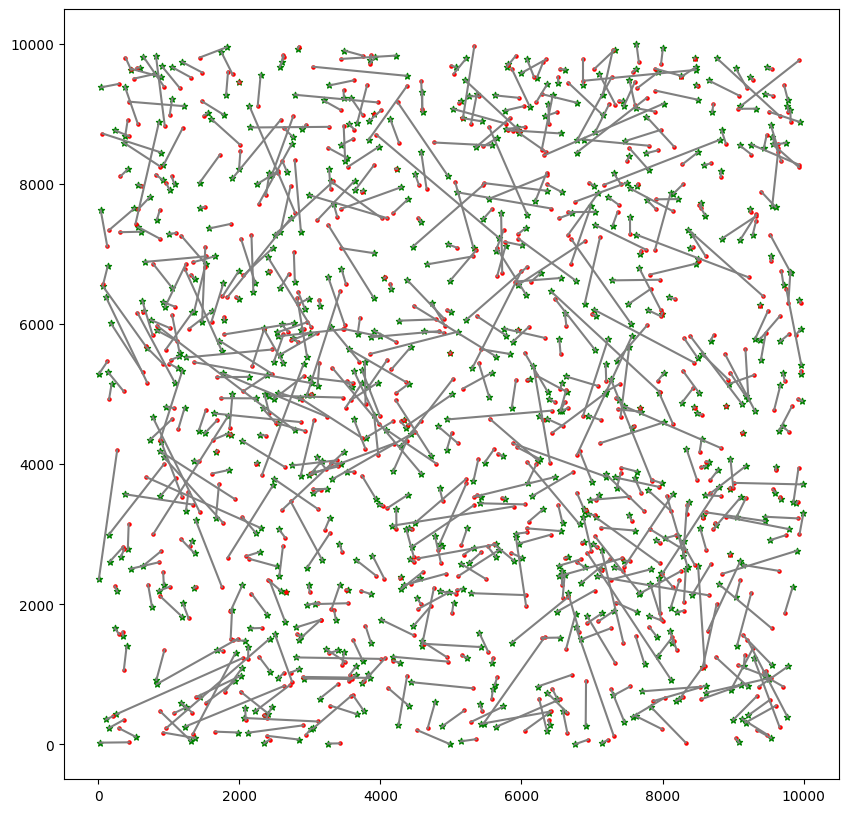

In [185]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np


def get_color(i):
    # colors = list(matplotlib.colors.CSS4_COLORS.values())
    colors = matplotlib.cm.tab20.colors
    return colors[i % len(colors)]


point_inds = list(range(env.N))  # longs_points[:]
corrects_np = np.array(env.coordinates)[point_inds]
estimates_np = np.array(x_best)[point_inds]
rectangles = np.array([env.rectangles[i] for i in range(env.N)])[point_inds]

# 四角形と、四角形内の正解点と予測点を描画
plt.figure(figsize=(10, 10))
ax = plt.gca()
# for i, rect in enumerate(rectangles):
#     l, r, t, b = rect
#     ax.add_patch(matplotlib.patches.Rectangle((l, t), r - l, b - t, alpha=0.1))
ax.scatter(corrects_np[:, 0], corrects_np[:, 1], color="green", label="correct", s=20, marker="*")
ax.scatter(estimates_np[:, 0], estimates_np[:, 1], color="red", label="estimate", s=5, marker="o")
for point_ind in range(len(corrects_np)):
    ax.plot(
        (corrects_np[point_ind, 0], estimates_np[point_ind, 0]),
        (corrects_np[point_ind, 1], estimates_np[point_ind, 1]),
        color="gray",
        label="correct path",
    )
plt.show()